# GPT Addition

**Reference:** [See a GPT's internals animated in 3D as you build](https://bbycroft.net/llm)

**Task:** Train a small Transformer to compute `a + b = c`.  
The model predicts the digits of `c` in **reverse order** (ones digit first),  
matching the right-to-left carry propagation of pencil-and-paper addition.

Key ideas:
- **Reversed output** — predicting `046` for sum `640` lets each output token depend only on carries from lower digits already seen.
- **Loss masking** — the question `NNN+NNN=` is masked out with `ignore_index=-1` in `CrossEntropyLoss`; only the answer digits are graded.
- **On-the-fly data** — each batch contains freshly sampled random problems; no `train.bin` / `val.bin` needed.

---

In [ ]:
import sys, os, math, random
sys.path.insert(0, '.')

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

from model    import GPT, GPTConfig
from config   import TrainConfig
from data     import make_problem, AdditionDataset, encode, decode, VOCAB, VOCAB_SIZE, stoi, itos, NDIGITS
from evaluate import evaluate

device = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {device}')


## 1. Data

Each problem is a fixed-length string `"NNN+NNN=RRRR"` where `RRRR` is the sum zero-padded and reversed.

In [ ]:
ndigits = 3
print(f'Vocab ({VOCAB_SIZE} tokens): {VOCAB!r}')
print(f'Token map: {stoi}')
print()
print('Example problems (a + b = c, encoded as string):')
print(f'  {"string":20s}  {"a":>5}  {"b":>5}  {"c":>5}  reversed-answer')
print('  ' + '-'*65)
for _ in range(12):
    s, a, b, c = make_problem(ndigits)
    ans_rev = s[s.index('=')+1:]
    print(f'  {s:20s}  {a:5d}  {b:5d}  {c:5d}  {ans_rev}')


In [ ]:
# Show how a problem gets tokenised and where the loss mask sits
s, a, b, c = make_problem(ndigits)
tokens = encode(s)
x_tok  = tokens[:-1]
y_tok  = tokens[1:]
eq_pos   = tokens.index(stoi['='])  # '=' position in tokens
mask_end = eq_pos                    # in y (shifted+1), answer starts at eq_pos

print(f'Problem string : {s!r}  (len={len(s)})')
print(f'x (input)      : {x_tok}')
print(f'y (target)     : {y_tok}')
print(f'y after masking: {[-1]*mask_end + y_tok[mask_end:]}')
print()
print('Position breakdown:')
for i, (xi, yi) in enumerate(zip(x_tok, y_tok)):
    masked = '(masked)' if i < mask_end else '<-- LOSS HERE'
    print(f'  pos {i:2d}: x={itos[xi]!r:2s}  y={itos[yi]!r:2s}  {masked}')


## 2. Model

A small 4-layer GPT.  Sequence length fits in a tiny block_size of `3*ndigits+2`.

In [4]:
block_size = 3 * ndigits + 2

cfg = GPTConfig(
    block_size = block_size,
    vocab_size  = VOCAB_SIZE,
    n_layer     = 4,
    n_head      = 4,
    n_embd      = 64,
)
model = GPT(cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Config     : {cfg}')
print(f'Parameters : {n_params:,}')
print(f'Block size : {block_size}  (sequence length during training)')

Config     : GPTConfig(block_size=11, vocab_size=12, n_layer=4, n_head=4, n_embd=64, dropout=0.0, bias=True)
Parameters : 201,536
Block size : 11  (sequence length during training)


## 3. Training

Two options:
- **Quick demo** (cell below) — ~5 000 steps, just enough to see the loss drop.
- **Full training** — run `python train_addition.py` in the terminal for 100 000 steps to get near-perfect accuracy.

In [ ]:
# ── Run config ──────────────────────────────────────────────────────────────
reverse_c  = True   # True = ones-first (reversed); False = standard left-to-right

# Trackers are on by default in train_addition.py — they silently skip if not
# installed. Disable here only if you want to suppress them in the notebook loop.
use_wandb  = True   # pip install wandb  →  wandb login
use_mlflow = True   # pip install mlflow →  mlflow ui  (localhost:5000)

run_tag = f'addition_{ndigits}digit_{"rev" if reverse_c else "fwd"}'
print(f'run_tag={run_tag}  reverse_c={reverse_c}  wandb={use_wandb}  mlflow={use_mlflow}')


In [ ]:
import glob as _glob

# ckpt_files = sorted(_glob.glob(f'checkpoints/{run_tag}_epoch*.pt'))
ckpt_filse='/Users/lior/projects/APEX/ex0-pre/checkpoints/addition_3digit_epoch0007.pt'
if ckpt_files:
    latest = ckpt_files[-1]
    ckpt = torch.load(latest, map_location=device, weights_only=True)
    model.load_state_dict(ckpt['model'])
    print(f'Loaded {latest}  (step {ckpt["step"]}). Skip to section 4.')
else:
    print('No checkpoint found — run the quick training cell below.')


In [ ]:
# Quick training loop — ~5 000 steps (adjust max_steps as you like)
# For a real run: python train_addition.py  (100k steps, ~10-20 min CPU)

from torch.utils.data import DataLoader

max_steps  = 5_000
batch_size = 128
lr         = 3e-4
log_every  = 500

# Re-init model fresh (comment out if you loaded a checkpoint above)
model = GPT(cfg).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)

dataset   = AdditionDataset(size=max_steps * batch_size, ndigits=ndigits, reverse_c=reverse_c)
loader    = DataLoader(dataset, batch_size=batch_size, num_workers=0)
data_iter = iter(loader)

losses_log = []
model.train()

for step in range(max_steps):
    # cosine LR
    lrs = lr * 0.5 * (1.0 + math.cos(math.pi * step / max_steps))
    for g in optimizer.param_groups:
        g['lr'] = lrs

    try:
        x, y = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        x, y = next(data_iter)
    x, y = x.to(device), y.to(device)

    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    losses_log.append(loss.item())

    if step % log_every == 0 or step == max_steps - 1:
        avg = sum(losses_log[-100:]) / min(len(losses_log), 100)
        acc = evaluate(model, ndigits=ndigits, device=device, n_samples=200, reverse_c=reverse_c)
    # to use full train() with tracker support:
    # from train_addition import train
    # model = train(ndigits=ndigits, max_iters=5_000, reverse_c=reverse_c, use_wandb=use_wandb, use_mlflow=use_mlflow)
        print(f'step {step:5d} | loss {avg:.4f} | acc {acc:.3f}')

# Plot training curve
smooth = np.convolve(losses_log, np.ones(50)/50, mode='valid')
plt.figure(figsize=(8, 3))
plt.plot(losses_log, alpha=0.3, label='raw')
plt.plot(smooth, label='smoothed (50-step)')
plt.xlabel('step'); plt.ylabel('loss'); plt.title('Training loss'); plt.legend()
plt.tight_layout(); plt.show()


## 4. Evaluation

Measure exact-match accuracy across random problems.

In [ ]:
acc = evaluate(model, ndigits=ndigits, n_samples=1_000, device=device, reverse_c=reverse_c)
order = 'reversed' if reverse_c else 'forward'
print(f'Accuracy ({order}) over 1000 random {ndigits}-digit problems: {acc*100:.1f}%')


In [ ]:
# Try specific examples
def add_with_gpt(a: int, b: int, nd: int = ndigits) -> int | None:
    """Ask the model to compute a+b and return its answer (or None if malformed)."""
    question = f"{a}+{b}="
    x = torch.tensor(encode(question), dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        out = model.generate(x, max_new_tokens=nd + 1, greedy=True)
    ans_tokens = out[0, len(question):].tolist()
    try:
        ans = decode(ans_tokens)
        return int(ans[::-1] if reverse_c else ans)
    except ValueError:
        return None

test_cases = [
    (1, 1), (9, 9), (123, 456), (999, 1), (500, 500),
    (999, 999), (42, 58), (100, 200), (0, 0),
]
print(f'  {"a":>6}  {"b":>6}  {"expected":>8}  {"got":>8}  ok?')
print('  ' + '-'*45)
for a, b in test_cases:
    expected = a + b
    got      = add_with_gpt(a, b)
    ok       = 'ok' if got == expected else 'WRONG'
    print(f'  {a:6d}  {b:6d}  {expected:8d}  {str(got):>8s}  {ok}')


In [30]:
# Try specific examples
def add_with_gpt(a: int, b: int, nd: int = ndigits) -> int | None:
    """Ask the model to compute a+b and return its answer (or None if malformed)."""
    question = f"{str(a)}+{str(b)}="
    x = torch.tensor(encode(question), dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        out = model.generate(x, max_new_tokens=nd + 1, greedy=True)
    ans_tokens = out[0, len(question):].tolist()
    try:
        return int(decode(ans_tokens)[::-1])  # un-reverse
    except ValueError:
        return None
add_with_gpt(1, 1)

4312

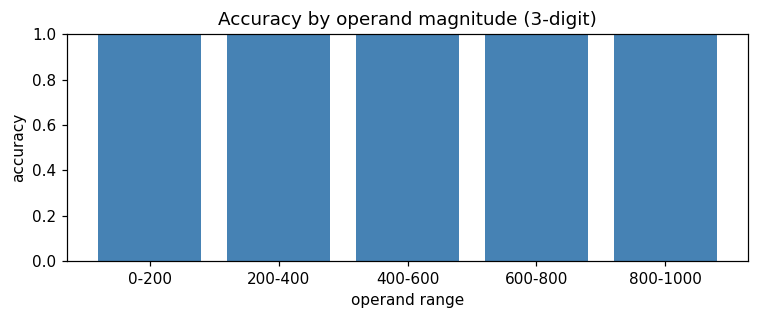

In [14]:
# Does accuracy vary by magnitude of the operands?
buckets = 5
bucket_size = 10**ndigits // buckets
results = []

for bucket in range(buckets):
    lo = bucket * bucket_size
    hi = lo + bucket_size
    correct, total = 0, 200
    for _ in range(total):
        a = random.randint(lo, hi - 1)
        b = random.randint(lo, hi - 1)
        got = add_with_gpt(a, b)
        correct += int(got == a + b)
    results.append((f'{lo}-{hi}', correct / total))

labels, accs = zip(*results)
plt.figure(figsize=(7, 3))
plt.bar(labels, accs, color='steelblue')
plt.ylim(0, 1); plt.ylabel('accuracy'); plt.xlabel('operand range')
plt.title(f'Accuracy by operand magnitude ({ndigits}-digit)')
plt.tight_layout(); plt.show()

## 5. Attention Patterns

Peek inside the model. For each layer/head, which input positions does the model  
attend to when predicting each output digit?

A well-trained model should show the output positions attending back to the  
corresponding digit columns of the operands.

In [ ]:
def get_attention_maps(problem_str: str):
    """
    Run one forward pass on `problem_str` (full sequence, including answer)
    and return a list of (n_head, T, T) attention tensors, one per layer.
    """
    tokens = encode(problem_str)
    x = torch.tensor(tokens[:-1], dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        model(x)  # triggers _last_attn capture in each CausalSelfAttention
    return [block.attn._last_attn[0].cpu() for block in model.transformer.h]


# Pick a concrete problem to inspect (no zero-padding on operands)
a_ex, b_ex = 123, 456
c_ex       = a_ex + b_ex
c_rev_str  = str(c_ex).zfill(ndigits + 1)[::-1]
prob_str   = f"{a_ex}+{b_ex}={c_rev_str}"
print(f'Problem: {prob_str}  ({a_ex} + {b_ex} = {c_ex}, reversed answer: {c_rev_str!r})')

attn_maps = get_attention_maps(prob_str)
seq_chars  = list(prob_str[:-1])  # x chars
print(f'Sequence characters: {seq_chars}')
print(f'Captured {len(attn_maps)} layers, each shape: {list(attn_maps[0].shape)}')


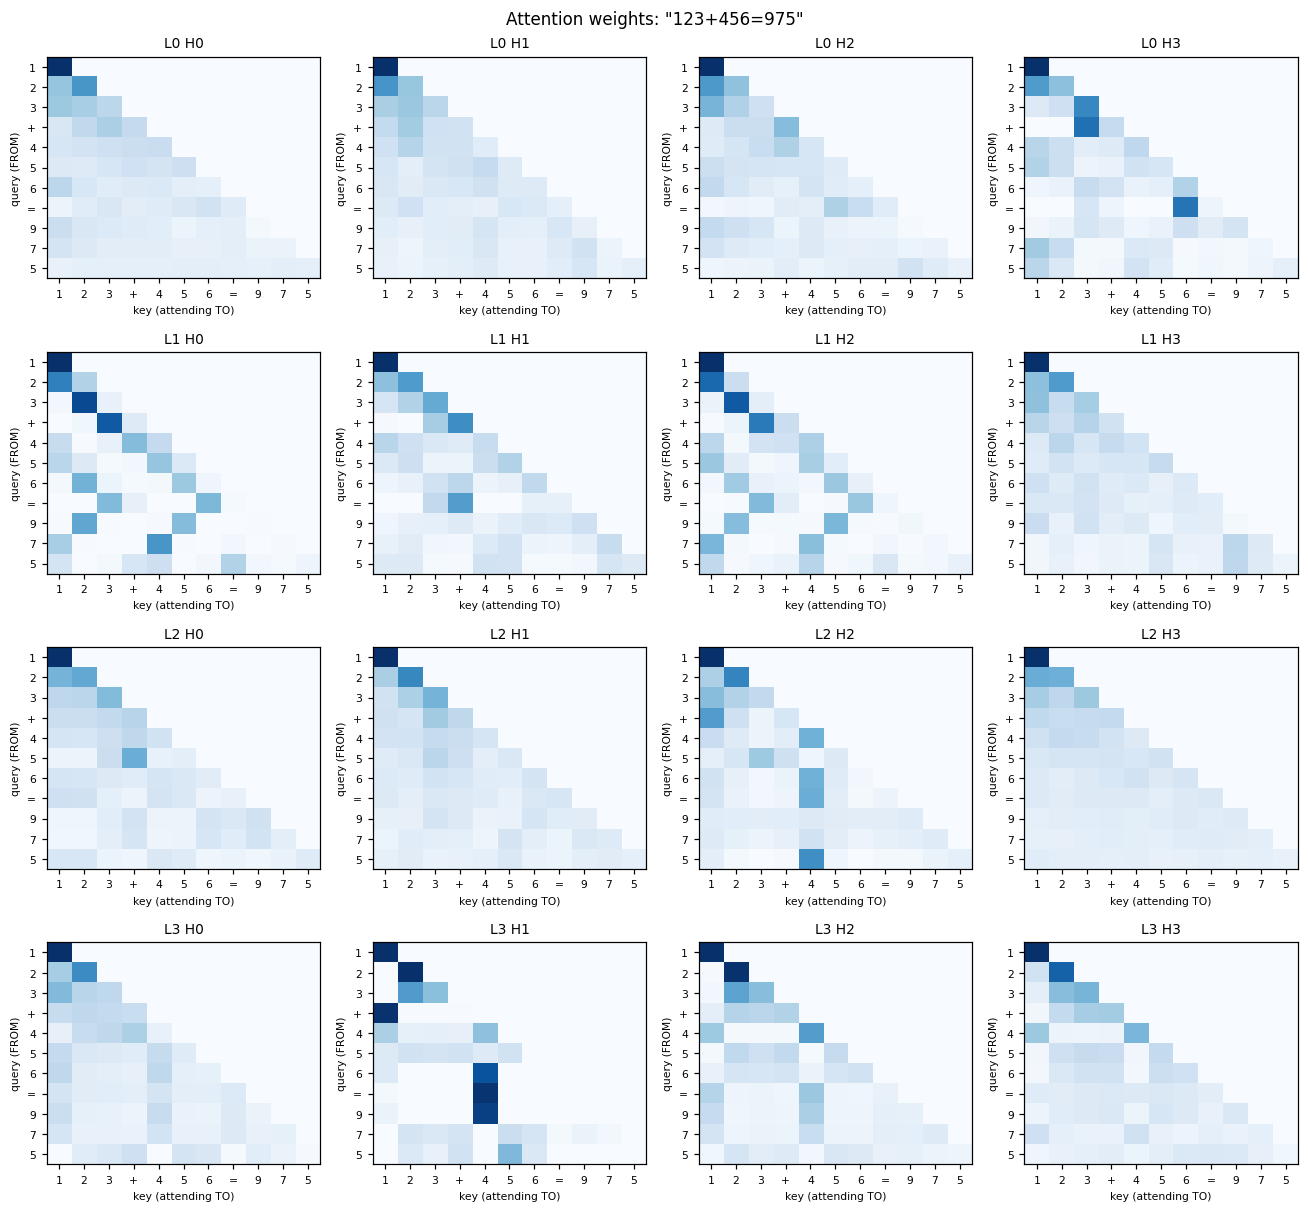

In [16]:
n_layers = len(attn_maps)
n_heads  = attn_maps[0].shape[0]
T        = attn_maps[0].shape[-1]

fig, axes = plt.subplots(n_layers, n_heads, figsize=(3 * n_heads, 2.8 * n_layers))

for layer_idx, attn in enumerate(attn_maps):
    for head_idx in range(n_heads):
        ax = axes[layer_idx][head_idx]
        data = attn[head_idx].numpy()  # (T, T)
        im = ax.imshow(data, vmin=0, vmax=data.max(), cmap='Blues', aspect='auto')
        ax.set_title(f'L{layer_idx} H{head_idx}', fontsize=9)
        ax.set_xticks(range(T)); ax.set_xticklabels(seq_chars, fontsize=7)
        ax.set_yticks(range(T)); ax.set_yticklabels(seq_chars, fontsize=7)
        ax.set_xlabel('key (attending TO)',  fontsize=7)
        ax.set_ylabel('query (FROM)', fontsize=7)

fig.suptitle(f'Attention weights: "{prob_str[:-1]}"', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Zoom in: average attention from answer positions back to input tokens.
# A good model should attend to the corresponding digit columns.

question_len = prob_str.index('=') + 1  # dynamic — works regardless of operand width
T            = attn_maps[0].shape[-1]
avg_attn     = torch.stack(attn_maps).mean(dim=0).mean(dim=0)  # (T, T) avg over layers & heads

ans_positions = list(range(question_len - 1, T))  # positions in x that precede answer tokens
ans_labels    = [seq_chars[p] for p in ans_positions]

fig, ax = plt.subplots(1, 1, figsize=(8, 2.5))
data = avg_attn[ans_positions, :].numpy()
im = ax.imshow(data, cmap='Oranges', aspect='auto', vmin=0)
ax.set_xticks(range(T));                       ax.set_xticklabels(seq_chars, fontsize=9)
ax.set_yticks(range(len(ans_positions)));      ax.set_yticklabels(ans_labels, fontsize=9)
ax.set_xlabel('attending TO (key position)', fontsize=9)
ax.set_ylabel('answer query', fontsize=9)
ax.set_title('Average attention: answer positions → input positions', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print('Answer chars :', list(prob_str[question_len:]))
print('(reversed — index 0 = ones digit of the sum)')
